# Sentence Similarity

## Goal
Word similarity is useful, but sentence similarity is more practical.
This experiment measures how similar two sentences are
using TF-IDF vectors and cosine similarity.

## Question
Can we find similar sentences without any pretrained model?

In [1]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Define Sentences
A small corpus covering different topics.

In [2]:
sentences = [
    "I love machine learning and artificial intelligence",
    "Deep learning is a subset of machine learning",
    "Natural language processing is fascinating",
    "I enjoy studying NLP and text analysis",
    "The weather today is sunny and warm",
    "It is a beautiful day outside",
    "Neural networks are inspired by the human brain",
    "The cat sat on the mat",
]

print(f"Total sentences: {len(sentences)}")
for i, s in enumerate(sentences):
    print(f"{i+1}, {s}")

Total sentences: 8
1, I love machine learning and artificial intelligence
2, Deep learning is a subset of machine learning
3, Natural language processing is fascinating
4, I enjoy studying NLP and text analysis
5, The weather today is sunny and warm
6, It is a beautiful day outside
7, Neural networks are inspired by the human brain
8, The cat sat on the mat


## 2. Compute Sentence Similarity

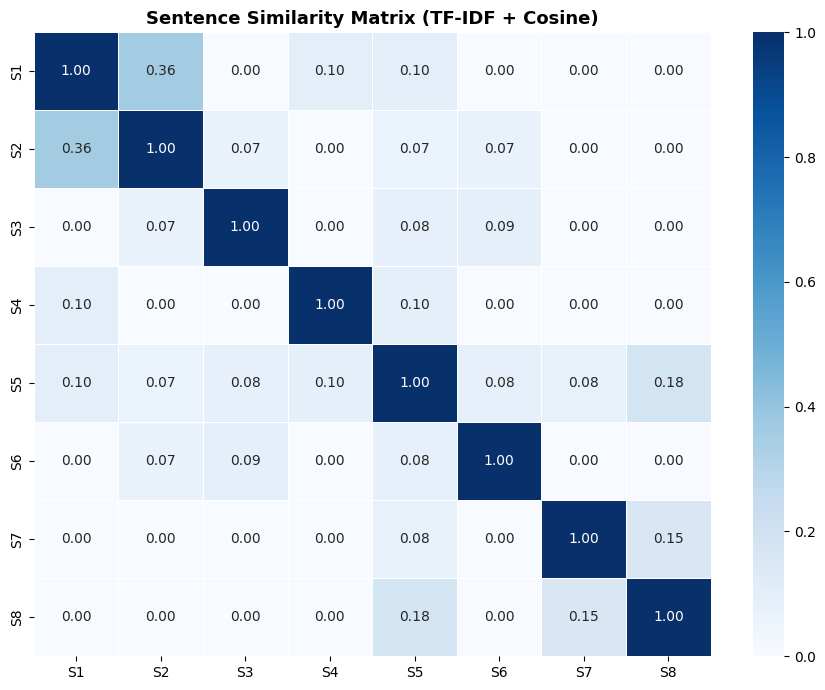

In [3]:
# Vectorize sentences with TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(sentences)

# Compute pairwise cosine similarity
sim_matrix = cosine_similarity(tfidf_matrix)

# Visualize
fig, ax = plt.subplots(figsize=(9, 7))
labels = [f"S{i+1}" for i in range(len(sentences))]

sns.heatmap(
    sim_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Sentence Similarity Matrix (TF-IDF + Cosine)",
            fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("sentence_similarity.png", dpi=300)
plt.show()

## 3. Find Most Similar Sentence to a Query

In [5]:
def find_most_similar(query: str, sentences: list, vectorizer, top_n: int = 3) -> list:
    """Find the most similar sentences to a query using TF-IDF + cosine similarity."""
    query_vec = vectorizer.transform([query])
    corpus_vecs = vectorizer.transform(sentences)
    similarities = cosine_similarity(query_vec, corpus_vecs)[0]

    top_indices = similarities.argsort()[::-1][:top_n]
    results = [(sentences[i], similarities[i])for i in top_indices]
    return results

# Test
query = "I am interested in deep learning and neural networks"
print(f"Query: {query}\n")
print(f"{'Sentence':<55} {'Score':>6}")
print("-" * 65)
for sentence, score in find_most_similar(query, sentences, vectorizer):
    print(f"{sentence:<55} {score:>6.3f}")

Query: I am interested in deep learning and neural networks

Sentence                                                 Score
-----------------------------------------------------------------
Deep learning is a subset of machine learning            0.445
Neural networks are inspired by the human brain          0.355
I love machine learning and artificial intelligence      0.269


## 4. Key Observations

| Query | Top Match | Score | Reason |
|-------|-----------|-------|--------|
| "deep learning and neural networks" | S2 | 0.445 | "deep learning" exact match |
| | S7 | 0.355 | "neural networks" exact match |
| | S1 | 0.269 | "learning" shared word |

## Key Insight
TF-IDF sentence similarity works well when sentences share exact words.
It fails when sentences are semantically similar but use different words.

Example of failure:
- "I enjoy studying NLP" (S4)
- "Natural language processing is fascinating" (S3)
- Similarity = 0.00 — but they are clearly about the same topic

This is the fundamental limitation TF-IDF cannot overcome.
Sentence transformers and embeddings solve this problem.

## Next
-> keyword_extraction.ipynb